In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [29]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [30]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_4.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657402,0.630655
1,3.900000e-09,0.715501,0.689965
2,5.900000e-09,0.768871,0.745672
3,7.900000e-09,0.815327,0.795434
4,9.900000e-09,0.852968,0.837213
...,...,...,...
535,6.390000e-08,0.675294,0.897332
536,6.590000e-08,0.495711,0.304343
537,6.790000e-08,0.732209,0.888625
538,6.990000e-08,0.441223,0.318401


In [31]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [32]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

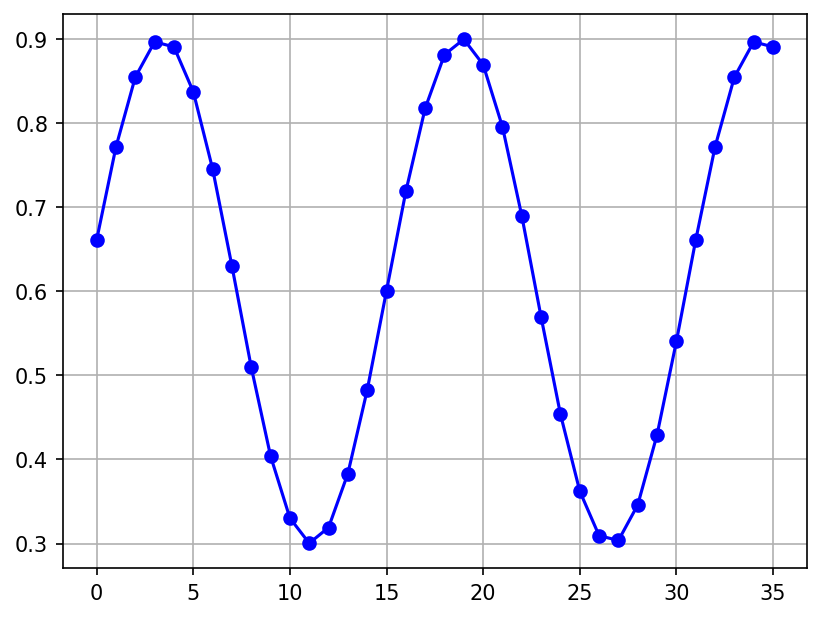

In [33]:
plt.plot(vo[1, :], "b-o")
plt.grid()
plt.show()

In [34]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

3.0907830334341116e-08
-4.856302328579675e-08
-1.0320900836262865e-07
2.062572139598684e-08
-1.3276166275791366e-06
3.3195648999226247e-09
-2.1263069614948227e-06
3.5830031779404755e-08
3.3466693145798664e-07
-2.1543730670102325e-06
1.7186386844959785e-06
1.658535028643986e-07
-4.5507643338969975e-06
7.931540881281191e-07
5.28078160010189e-07
-6.098558815010648e-07
-2.3514773212738612e-07
-7.723095238716207e-08
-1.6436467036980514e-06
5.157293167475934e-06
1.3004282983568681e-05
-2.3763629863509053e-05
3.2968310181319425e-05
3.824416004827527e-06
5.845900882280671e-07
1.7015403267939597e-06
5.817176079826119e-06
1.223680486955859e-05
-1.0921357139678807e-05
-1.2024463789411448e-05


In [35]:
# Analytical data
vov = 0.734
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
c = 1.3e-12
cb = 400e-15
cp =  20e-15
fbw = 6.1e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb+0.2)**2)
print(fbw/1e6)

6100.0


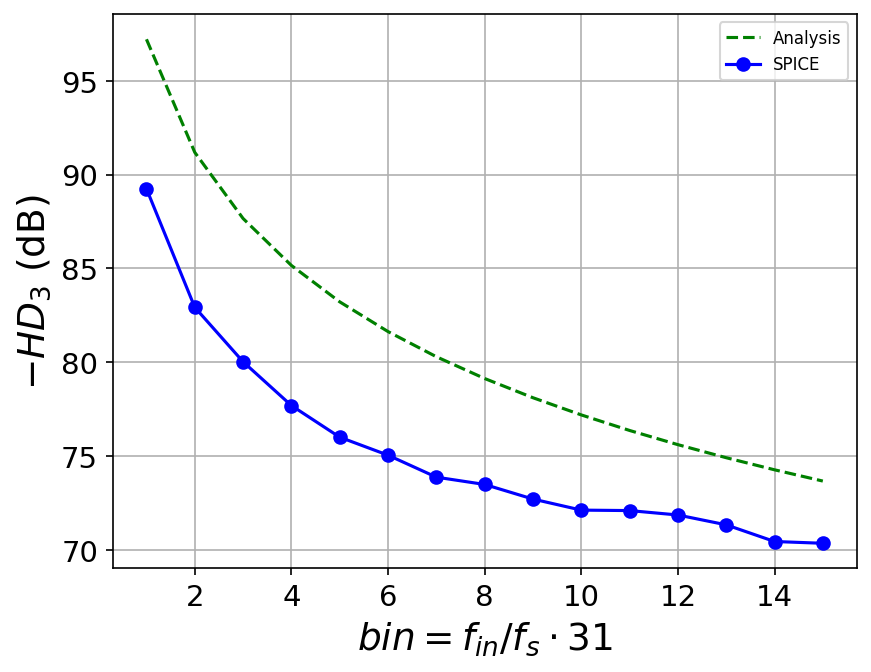

In [36]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "b-o", label='SPICE')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(60, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-6.098558815010648e-07
-2.3514773212738612e-07
-7.723095238716207e-08
-1.6436467036980514e-06
5.157293167475934e-06
1.3004282983568681e-05
-2.3763629863509053e-05
3.2968310181319425e-05
3.824416004827527e-06
5.845900882280671e-07
1.7015403267939597e-06
5.817176079826119e-06
1.223680486955859e-05
-1.0921357139678807e-05
-1.2024463789411448e-05


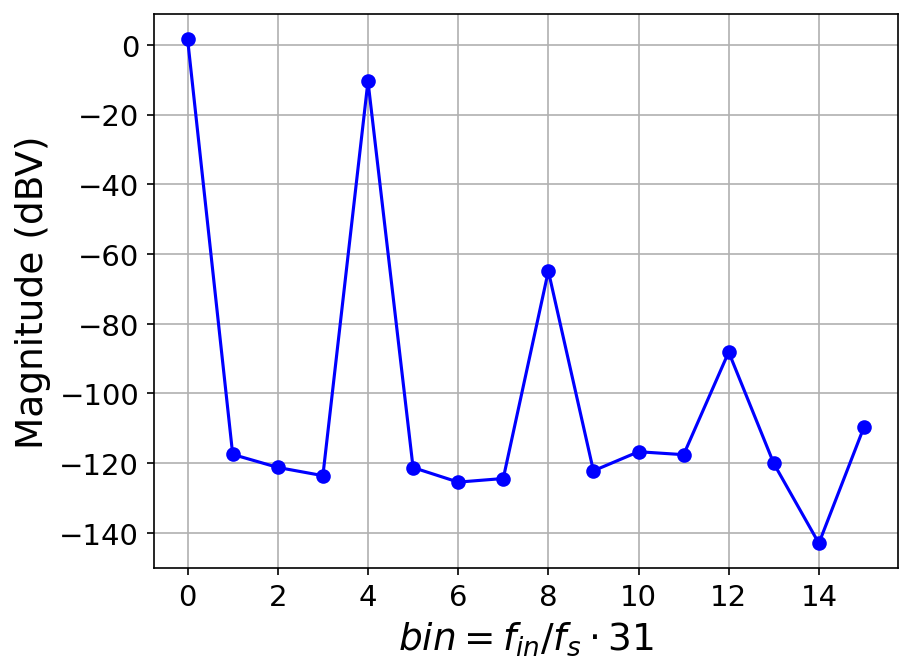

In [37]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
